In [4]:
# ============================================================
#  HR EMPLOYEE ATTRITION ANALYSIS
#  Phase 2 — Complete Exploratory Data Analysis (EDA)
#  Dataset: WA_Fn-UseC_-HR-Employee-Attrition.csv
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
 
PALETTE = {'No': '#1D9E75', 'Yes': '#E24B4A'}
C_RED, C_GREEN, C_BLUE, C_ORG, C_PUR = \
    '#E24B4A', '#1D9E75', '#185FA5', '#EF9F27', '#9B3EC2'

In [5]:
# ── Load & clean (Phase 1 output) ────────────────────────────
df = pd.read_csv('HR Analytics - Predict Employee Attrition.csv')
df.drop(['EmployeeCount','Over18','StandardHours','EmployeeNumber'],
        axis=1, inplace=True)
df['Attr_num'] = (df['Attrition'] == 'Yes').astype(int)
 
print("✅ Data loaded  —  Shape:", df.shape)
print(f"   Attrition rate: {df['Attr_num'].mean()*100:.1f}%\n")
 

✅ Data loaded  —  Shape: (1470, 32)
   Attrition rate: 16.1%



── Chart 1: Attrition Distribution ─────────────────────


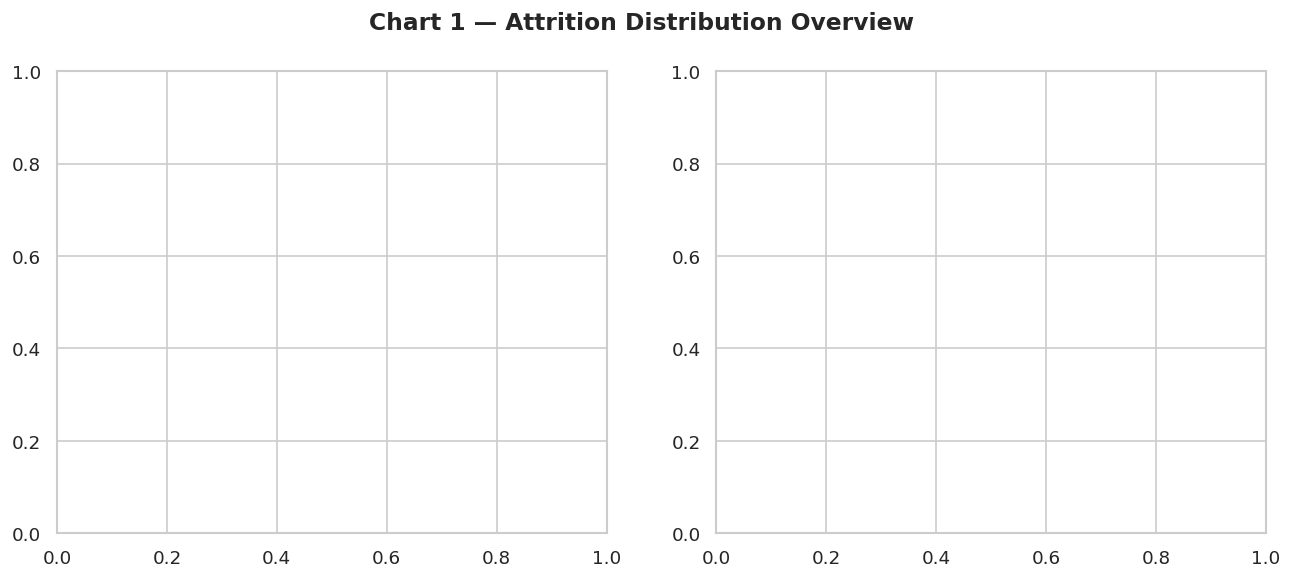

In [6]:
# ════════════════════════════════════════════════════════════
#  CHART 1 — Attrition Distribution
# ════════════════════════════════════════════════════════════
print("── Chart 1: Attrition Distribution ─────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1 — Attrition Distribution Overview',
             fontsize=14, fontweight='bold')
 
counts = df['Attrition'].value_counts()
 

In [7]:
 #Donut
wedges, texts, autotexts = axes[0].pie(
    counts.values,
    labels=[f'Stayed\n({counts["No"]:,})', f'Left\n({counts["Yes"]:,})'],
    colors=[C_GREEN, C_RED],
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.72,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.55},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white')
axes[0].text(0, 0, '1,470\nEmployees', ha='center', va='center',
             fontsize=12, fontweight='bold', color='#333')
axes[0].set_title('Employee Attrition Split', fontweight='bold')
 

Text(0.5, 1.0, 'Employee Attrition Split')

In [8]:
# Annotated bar
bars = axes[1].bar(['Stayed', 'Left'], counts.values,
                    color=[C_GREEN, C_RED], width=0.45, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15, f'{val:,}',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Count of Employees', fontweight='bold')
axes[1].set_ylabel('Number of Employees')
axes[1].set_ylim(0, counts.max() * 1.15)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_chart1_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart1_distribution.png\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_chart1_distribution.png



── Chart 2: OverTime Analysis ───────────────────────────


Text(0.5, 0.98, 'Chart 2 — OverTime: The #1 Driver of Attrition')

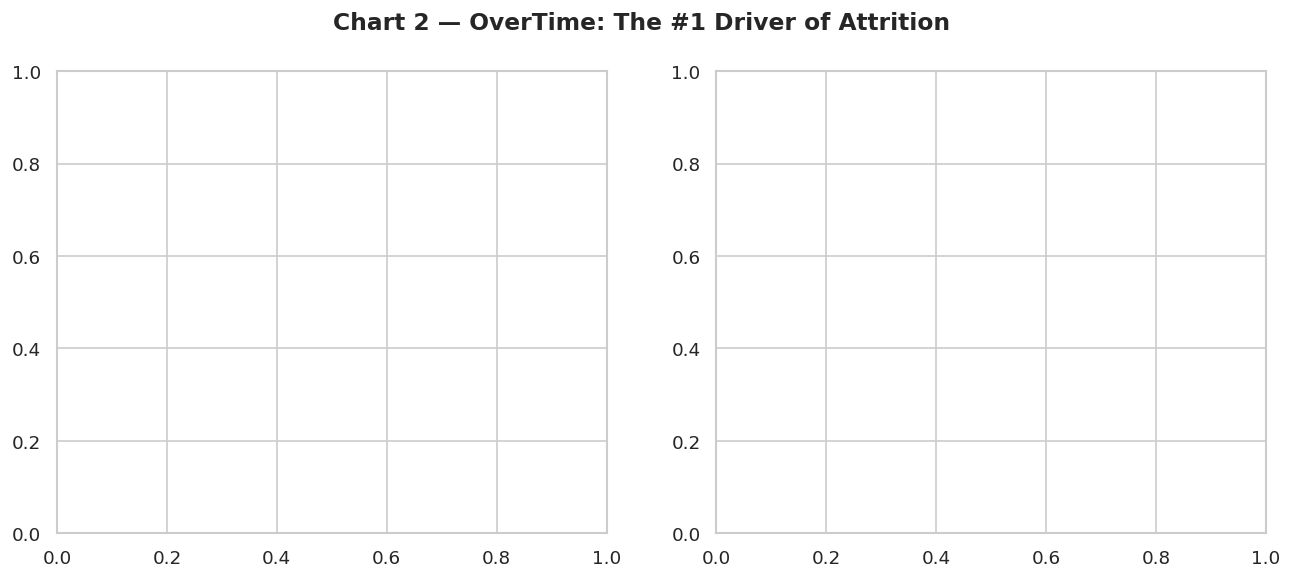

In [9]:
# ════════════════════════════════════════════════════════════
#  CHART 2 — OverTime: The #1 Attrition Driver
# ════════════════════════════════════════════════════════════
print("── Chart 2: OverTime Analysis ───────────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 2 — OverTime: The #1 Driver of Attrition',
             fontsize=14, fontweight='bold')
 

In [10]:
# Count plot
sns.countplot(x='OverTime', hue='Attrition', data=df,
              palette=PALETTE, ax=axes[0], width=0.5,
              edgecolor='white')
axes[0].set_title('Attrition Count by OverTime', fontweight='bold')
axes[0].set_xlabel('OverTime')
axes[0].legend(title='Attrition')
sns.despine(ax=axes[0])
 

In [11]:
# Rate bar
ot_rate = df.groupby('OverTime')['Attr_num'].mean() * 100
colors_ot = [C_GREEN if v < 15 else C_RED for v in ot_rate.values]
bars = axes[1].bar(ot_rate.index, ot_rate.values,
                    color=colors_ot, width=0.4, edgecolor='white')
for bar, val in zip(bars, ot_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=14)
axes[1].axhline(16.1, linestyle='--', color='grey',
                alpha=0.6, label='Avg 16.1%')
axes[1].set_title('Attrition RATE by OverTime', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 42)
axes[1].legend()
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_chart2_overtime.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart2_overtime.png")
print("   🔑 Key insight: OverTime=Yes → 30.5% vs 10.4% (3× gap)\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_chart2_overtime.png
   🔑 Key insight: OverTime=Yes → 30.5% vs 10.4% (3× gap)



── Chart 3: Department & Job Role ───────────────────────


Text(0.5, 0.98, 'Chart 3 — Department & Job Role Attrition Rates')

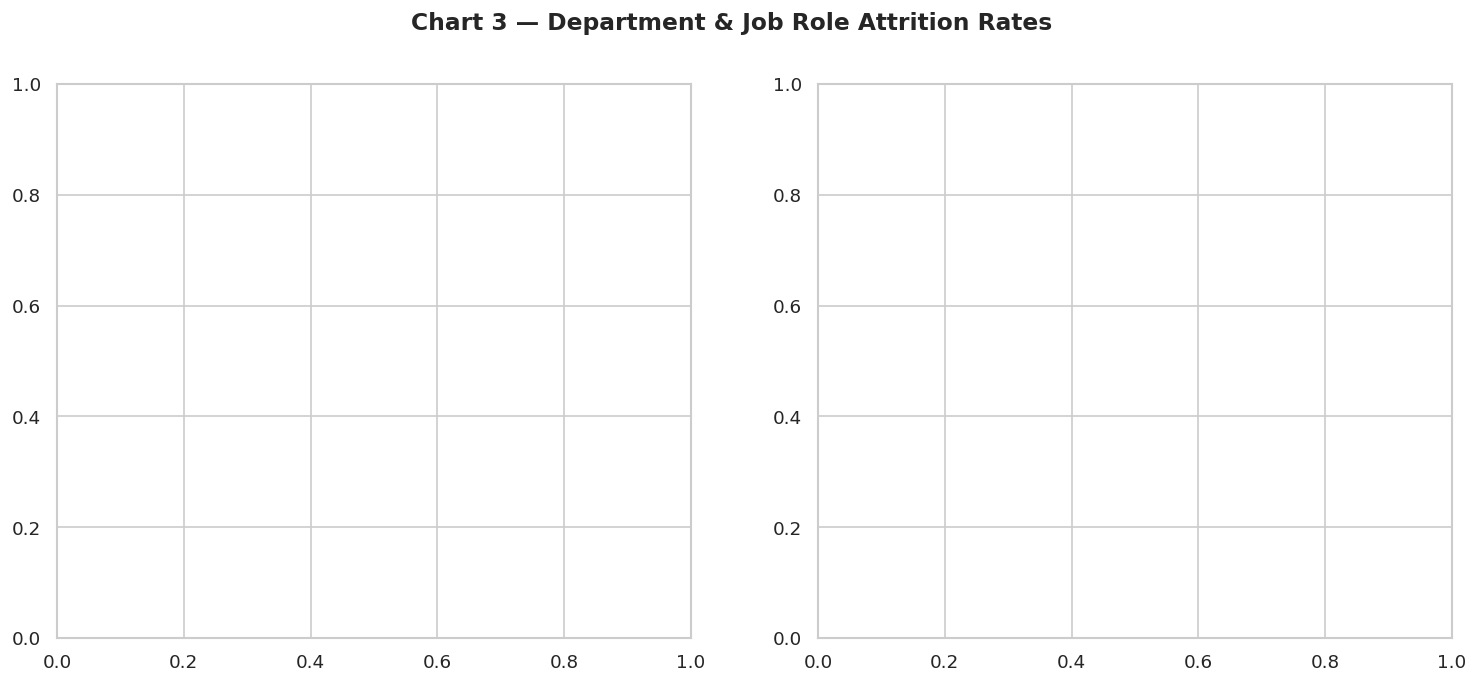

In [12]:
# ════════════════════════════════════════════════════════════
#  CHART 3 — Department & Job Role Analysis
# ════════════════════════════════════════════════════════════
print("── Chart 3: Department & Job Role ───────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Chart 3 — Department & Job Role Attrition Rates',
             fontsize=14, fontweight='bold')
 

In [13]:
# Department
dept_rate = df.groupby('Department')['Attr_num'].mean() * 100
colors_d = [C_RED if v > 18 else C_ORG if v > 14 else C_GREEN
            for v in dept_rate.values]
bars = axes[0].bar(dept_rate.index, dept_rate.values,
                    color=colors_d, width=0.45, edgecolor='white')
for bar, val in zip(bars, dept_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].axhline(16.1, linestyle='--', color='grey',
                alpha=0.6, label='Avg 16.1%')
axes[0].set_title('Attrition Rate by Department', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 30)
axes[0].legend()
sns.despine(ax=axes[0])
 

In [14]:
# Job Role — horizontal bar (sorted)
role_rate = (df.groupby('JobRole')['Attr_num']
               .mean() * 100).sort_values(ascending=True)
colors_r = [C_RED if v > 20 else C_ORG if v > 12 else C_GREEN
            for v in role_rate.values]
bars = axes[1].barh(role_rate.index, role_rate.values,
                     color=colors_r, edgecolor='white', height=0.65)
for bar, val in zip(bars, role_rate.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
axes[1].axvline(16.1, linestyle='--', color='grey', alpha=0.6)
axes[1].set_title('Attrition Rate by Job Role', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_xlim(0, 52)
legend_patches = [
    mpatches.Patch(color=C_RED,   label='High risk (>20%)'),
    mpatches.Patch(color=C_ORG,   label='Medium risk (12–20%)'),
    mpatches.Patch(color=C_GREEN, label='Low risk (<12%)'),
]
axes[1].legend(handles=legend_patches, fontsize=9)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_chart3_dept_role.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart3_dept_role.png")
print("   🔑 Key: Sales Rep=39.8%  |  Research Director=2.5%  |  Sales dept=20.6%\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_chart3_dept_role.png
   🔑 Key: Sales Rep=39.8%  |  Research Director=2.5%  |  Sales dept=20.6%



── Chart 4: Age & Job Level ─────────────────────────────


Text(0.5, 0.98, 'Chart 4 — Age & Job Level: Junior Employees Leave More')

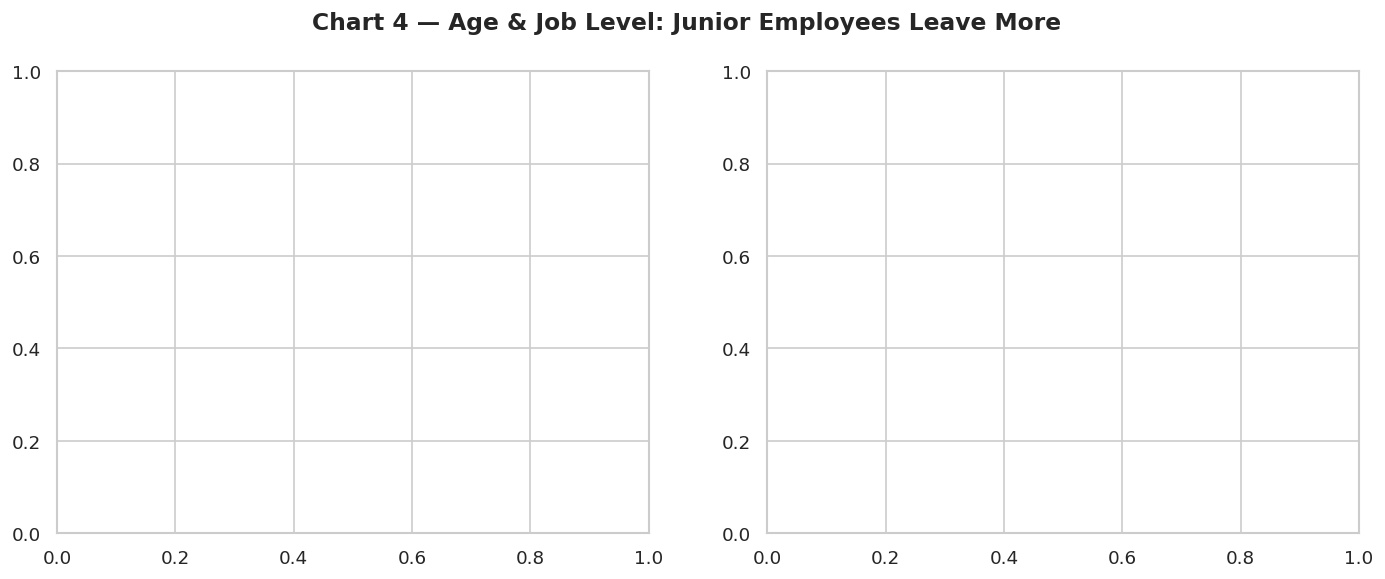

In [15]:
# ════════════════════════════════════════════════════════════
#  CHART 4 — Age & Job Level Analysis
# ════════════════════════════════════════════════════════════
print("── Chart 4: Age & Job Level ─────────────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 4 — Age & Job Level: Junior Employees Leave More',
             fontsize=14, fontweight='bold')

In [16]:
# Age histogram
sns.histplot(data=df, x='Age', hue='Attrition', bins=25,
             palette=PALETTE, ax=axes[0], alpha=0.75, edgecolor='white')
axes[0].axvline(33.6, color=C_RED,   linestyle='--', lw=2,
                label='Avg Left: 33.6 yrs')
axes[0].axvline(37.6, color=C_GREEN, linestyle='--', lw=2,
                label='Avg Stayed: 37.6 yrs')
axes[0].set_title('Age Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

In [17]:
# Job Level attrition rate
jl_rate = df.groupby('JobLevel')['Attr_num'].mean() * 100
colors_jl = [C_RED if v > 20 else C_ORG if v > 12 else C_GREEN
             for v in jl_rate.values]
bars = axes[1].bar([f'Level {i}' for i in jl_rate.index],
                    jl_rate.values,
                    color=colors_jl, width=0.5, edgecolor='white')
for bar, val in zip(bars, jl_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].axhline(16.1, linestyle='--', color='grey',
                alpha=0.6, label='Avg 16.1%')
axes[1].set_title('Attrition Rate by Job Level', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 36)
axes[1].legend()
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('hr_chart4_age_joblevel.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart4_age_joblevel.png")
print("   🔑 Key: 18-25 age group=34.8%  |  JobLevel 1=26.3%  |  Level 4=4.7%\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_chart4_age_joblevel.png
   🔑 Key: 18-25 age group=34.8%  |  JobLevel 1=26.3%  |  Level 4=4.7%



── Chart 5: Income, Tenure & Experience ─────────────────


Text(0.5, 0.98, 'Chart 5 — Compensation & Experience vs Attrition')

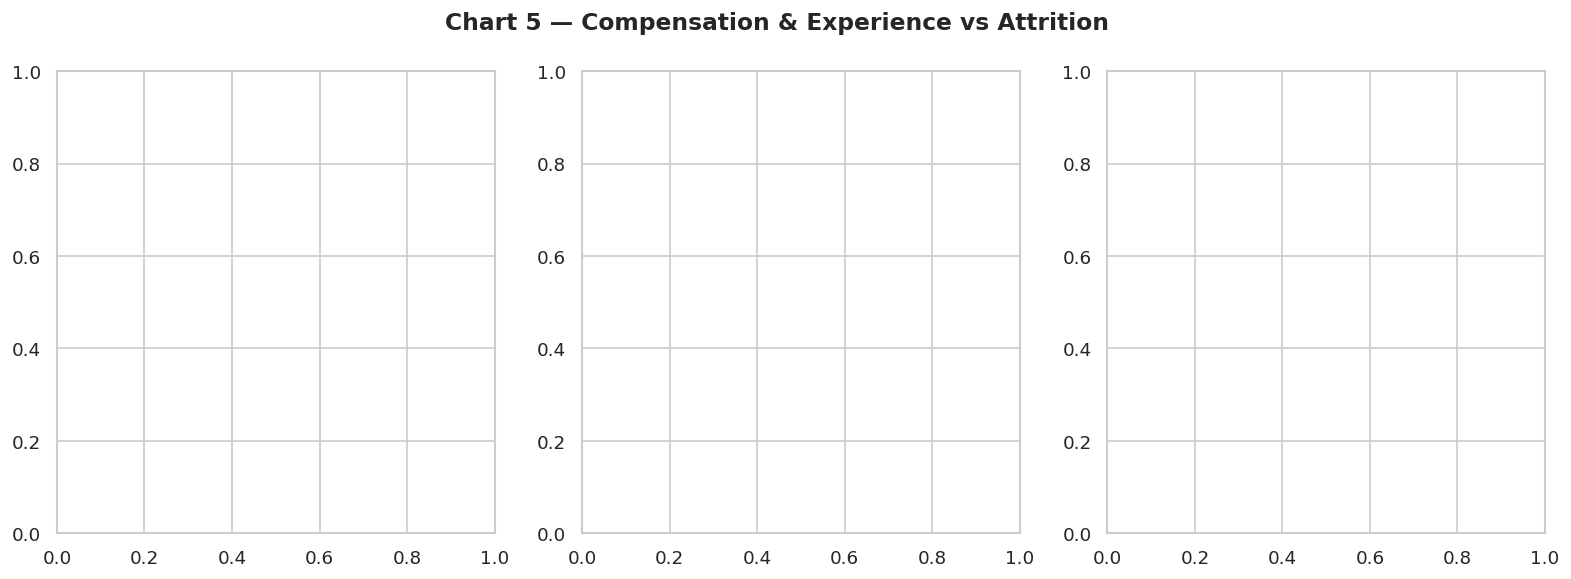

In [18]:
# ════════════════════════════════════════════════════════════
#  CHART 5 — Income, Tenure & Working Years
# ════════════════════════════════════════════════════════════
print("── Chart 5: Income, Tenure & Experience ─────────────────")
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 5 — Compensation & Experience vs Attrition',
             fontsize=14, fontweight='bold')

In [19]:
# Monthly Income boxplot
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette=PALETTE, ax=axes[0], width=0.5)
for i, attr in enumerate(['No', 'Yes']):
    med = df[df['Attrition'] == attr]['MonthlyIncome'].median()
    axes[0].text(i, med + 150, f'${med:,.0f}', ha='center',
                 fontsize=9, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#333', alpha=0.8))
axes[0].set_title('Monthly Income', fontweight='bold')
axes[0].set_ylabel('Monthly Income ($)')
sns.despine(ax=axes[0])

In [20]:
# Years at Company
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition',
             bins=20, palette=PALETTE, ax=axes[1],
             alpha=0.75, edgecolor='white')
axes[1].axvline(5.1, color=C_RED,   linestyle='--', lw=2, label='Left: 5.1 yrs')
axes[1].axvline(7.4, color=C_GREEN, linestyle='--', lw=2, label='Stayed: 7.4 yrs')
axes[1].set_title('Years at Company', fontweight='bold')
axes[1].set_xlabel('Years at Company')
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1])

In [21]:
# Total Working Years
sns.boxplot(x='Attrition', y='TotalWorkingYears', data=df,
            palette=PALETTE, ax=axes[2], width=0.5)
for i, attr in enumerate(['No', 'Yes']):
    mean_val = df[df['Attrition'] == attr]['TotalWorkingYears'].mean()
    axes[2].text(i, mean_val + 0.3, f'Avg {mean_val:.1f}yr',
                 ha='center', fontsize=9, fontweight='bold',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#333', alpha=0.8))
axes[2].set_title('Total Working Years', fontweight='bold')
axes[2].set_ylabel('Total Working Years')
sns.despine(ax=axes[2])
 
plt.tight_layout()
plt.savefig('hr_chart5_income_tenure.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart5_income_tenure.png")
print("   🔑 Key: Left avg $4,787/mo vs Stayed $6,833  |  Tenure 5.1 vs 7.4 yrs\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_chart5_income_tenure.png
   🔑 Key: Left avg $4,787/mo vs Stayed $6,833  |  Tenure 5.1 vs 7.4 yrs



── Chart 6: Personal Factors ────────────────────────────


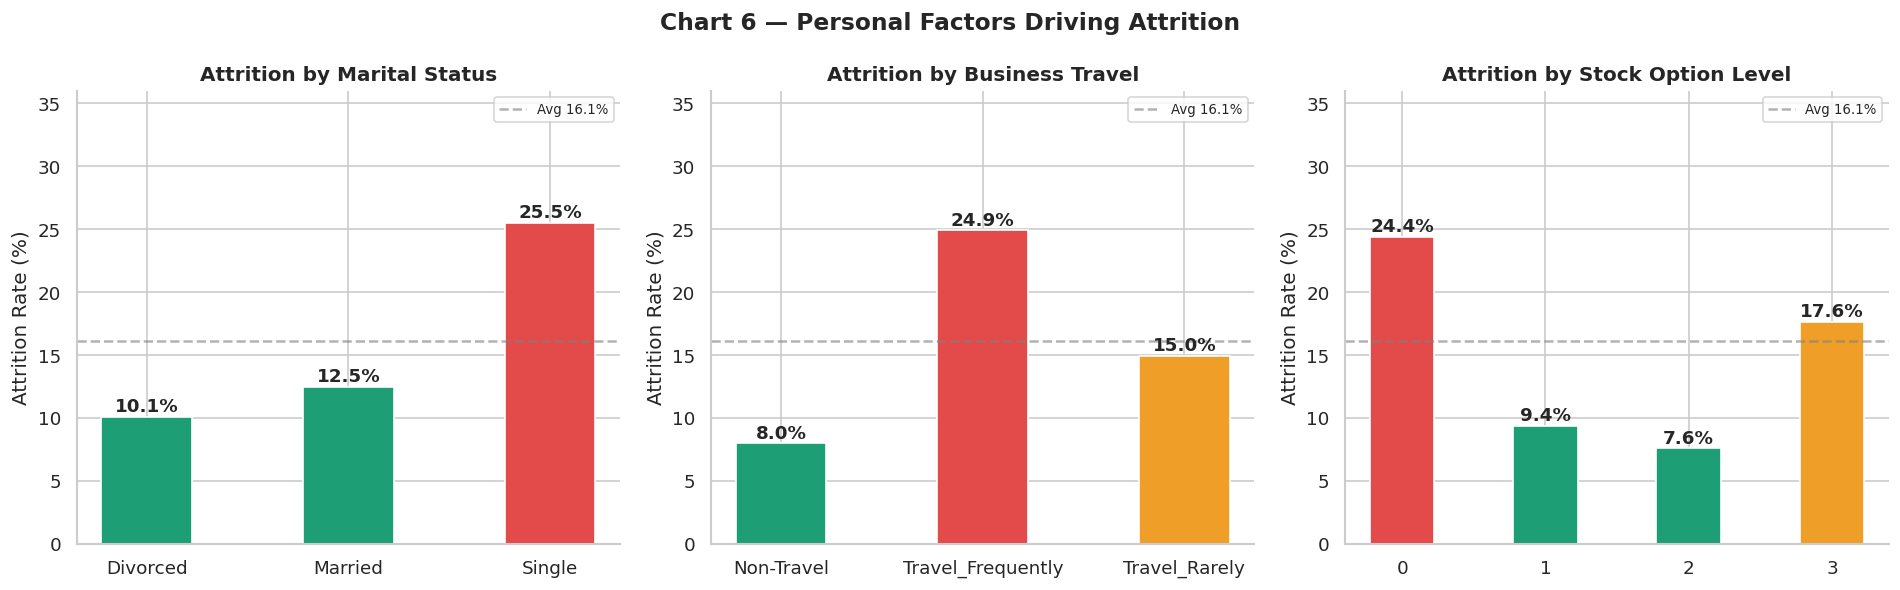

   ✅ Saved: hr_chart6_personal_factors.png
   🔑 Key: Single=25.5%  |  Freq Travel=24.9%  |  No Stock Options=24.4%



In [22]:
# ════════════════════════════════════════════════════════════
#  CHART 6 — Marital Status, Business Travel & Stock Options
# ════════════════════════════════════════════════════════════
print("── Chart 6: Personal Factors ────────────────────────────")
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 6 — Personal Factors Driving Attrition',
             fontsize=14, fontweight='bold')
 
for ax, col, title in zip(
    axes,
    ['MaritalStatus', 'BusinessTravel', 'StockOptionLevel'],
    ['Marital Status', 'Business Travel', 'Stock Option Level']
):
    rate = df.groupby(col)['Attr_num'].mean() * 100
    bar_colors = [C_RED if v > 20 else C_ORG if v > 14 else C_GREEN
                  for v in rate.values]
    bars = ax.bar([str(x) for x in rate.index], rate.values,
                   color=bar_colors, width=0.45, edgecolor='white')
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
    ax.axhline(16.1, linestyle='--', color='grey',
               alpha=0.6, label='Avg 16.1%')
    ax.set_title(f'Attrition by {title}', fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_ylim(0, 36)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('hr_chart6_personal_factors.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart6_personal_factors.png")
print("   🔑 Key: Single=25.5%  |  Freq Travel=24.9%  |  No Stock Options=24.4%\n")
 

── Chart 7: Satisfaction Scores ─────────────────────────


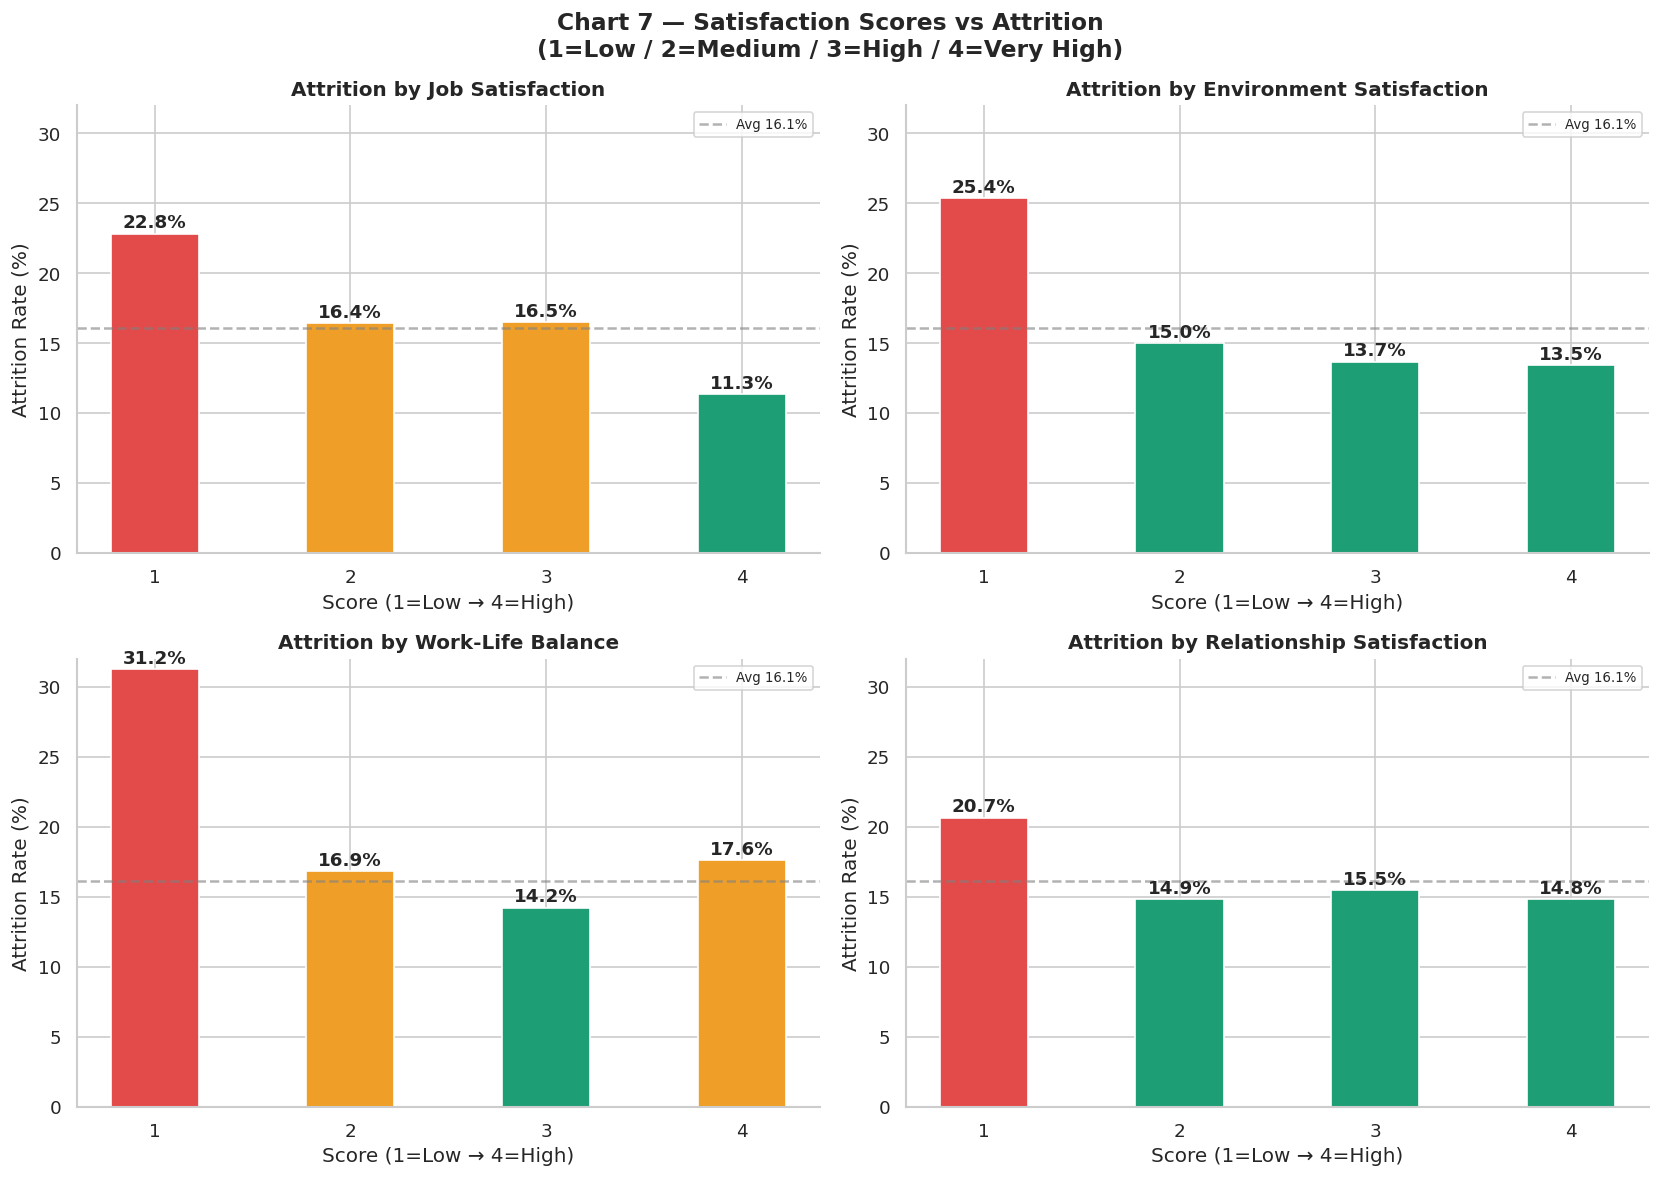

   ✅ Saved: hr_chart7_satisfaction.png
   🔑 Key: Low JobSat=22.8%  |  Low EnvSat=25.4%  |  Low WLB=31.2%



In [23]:
# ════════════════════════════════════════════════════════════
#  CHART 7 — Satisfaction Scores Analysis
# ════════════════════════════════════════════════════════════
print("── Chart 7: Satisfaction Scores ─────────────────────────")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chart 7 — Satisfaction Scores vs Attrition\n'
             '(1=Low / 2=Medium / 3=High / 4=Very High)',
             fontsize=14, fontweight='bold')
 
sat_cols = {
    'JobSatisfaction':          ('Job Satisfaction',         axes[0][0]),
    'EnvironmentSatisfaction':  ('Environment Satisfaction', axes[0][1]),
    'WorkLifeBalance':          ('Work-Life Balance',        axes[1][0]),
    'RelationshipSatisfaction': ('Relationship Satisfaction',axes[1][1]),
}
 
for col, (title, ax) in sat_cols.items():
    rate = df.groupby(col)['Attr_num'].mean() * 100
    bar_colors = [C_RED if v > 20 else C_ORG if v > 16 else C_GREEN
                  for v in rate.values]
    bars = ax.bar([str(x) for x in rate.index], rate.values,
                   color=bar_colors, width=0.45, edgecolor='white')
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
    ax.axhline(16.1, linestyle='--', color='grey',
               alpha=0.6, label='Avg 16.1%')
    ax.set_title(f'Attrition by {title}', fontweight='bold')
    ax.set_xlabel('Score (1=Low → 4=High)')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_ylim(0, 32)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('hr_chart7_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart7_satisfaction.png")
print("   🔑 Key: Low JobSat=22.8%  |  Low EnvSat=25.4%  |  Low WLB=31.2%\n")

── Chart 8: Correlation Heatmap ─────────────────────────


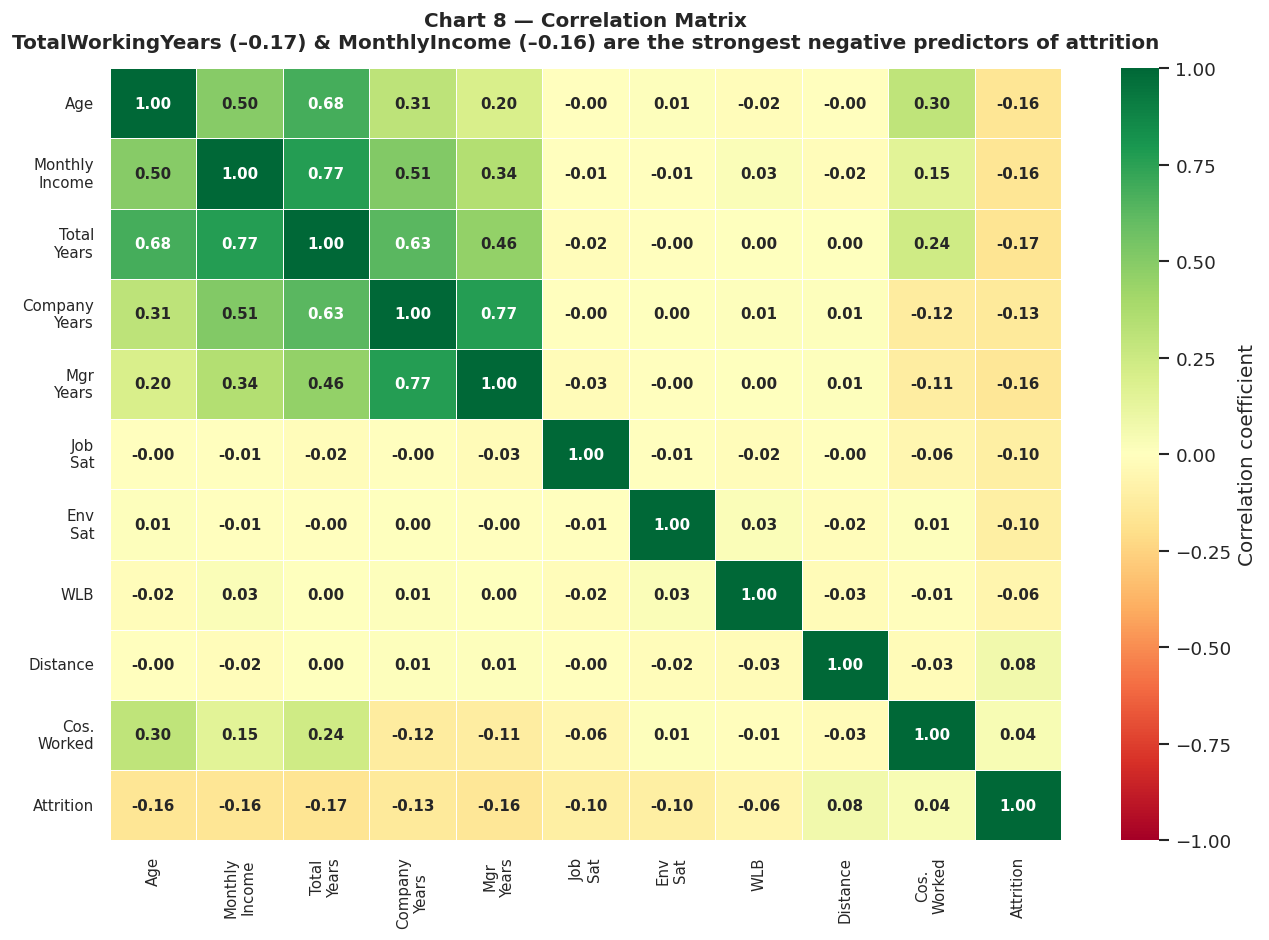

   ✅ Saved: hr_chart8_correlation.png



In [24]:
# ════════════════════════════════════════════════════════════
#  CHART 8 — Correlation Heatmap
# ════════════════════════════════════════════════════════════
print("── Chart 8: Correlation Heatmap ─────────────────────────")
 
corr_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
             'YearsAtCompany', 'YearsWithCurrManager',
             'JobSatisfaction', 'EnvironmentSatisfaction',
             'WorkLifeBalance', 'DistanceFromHome',
             'NumCompaniesWorked', 'Attr_num']
 
corr_matrix = df[corr_cols].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
 
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Correlation coefficient'}
)
labels = ['Age', 'Monthly\nIncome', 'Total\nYears',
          'Company\nYears', 'Mgr\nYears',
          'Job\nSat', 'Env\nSat',
          'WLB', 'Distance', 'Cos.\nWorked', 'Attrition']
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9, rotation=0)
ax.set_title('Chart 8 — Correlation Matrix\n'
             'TotalWorkingYears (–0.17) & MonthlyIncome (–0.16) '
             'are the strongest negative predictors of attrition',
             fontsize=12, fontweight='bold', pad=12)
 
plt.tight_layout()
plt.savefig('hr_chart8_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart8_correlation.png\n")

In [25]:
# ════════════════════════════════════════════════════════════
#  CHART 9 — Executive EDA Dashboard
# ════════════════════════════════════════════════════════════
print("── Chart 9: Executive Dashboard ─────────────────────────")
 
fig = plt.figure(figsize=(18, 11))
fig.suptitle('HR Attrition — Executive EDA Dashboard',
             fontsize=17, fontweight='bold', y=1.01)
 
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(3, 4, figure=fig,
                        hspace=0.55, wspace=0.4,
                        top=0.94, bottom=0.06,
                        left=0.06, right=0.97)
 

── Chart 9: Executive Dashboard ─────────────────────────


<Figure size 2160x1320 with 0 Axes>

In [26]:
# ── KPI boxes (row 0) ───────────────────────────────────────
kpis = [
    ('16.1%',   'Attrition Rate',       '#E24B4A'),
    ('237',     'Employees Left',        '#185FA5'),
    ('30.5%',   'OT Attrition Rate',    '#EF9F27'),
    ('39.8%',   'Sales Rep Rate',       '#9B3EC2'),
]
for i, (val, lbl, col) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(col)
    ax_k.text(0.5, 0.62, val, ha='center', va='center',
              fontsize=22, fontweight='bold', color='white',
              transform=ax_k.transAxes)
    ax_k.text(0.5, 0.22, lbl, ha='center', va='center',
              fontsize=10, color='white', alpha=0.85,
              transform=ax_k.transAxes)
    ax_k.set_xticks([]); ax_k.set_yticks([])
    for sp in ax_k.spines.values(): sp.set_visible(False)

In [27]:
# ── Row 1: OverTime | Department | Age Group ────────────────
# OverTime rate
ax1 = fig.add_subplot(gs[1, 0])
ot = df.groupby('OverTime')['Attr_num'].mean() * 100
ax1.bar(['No OT', 'OT'], ot.values,
         color=[C_GREEN, C_RED], edgecolor='white', width=0.5)
for i, v in enumerate(ot.values):
    ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center',
             fontweight='bold', fontsize=11)
ax1.set_title('OverTime', fontweight='bold')
ax1.set_ylabel('Attrition %'); ax1.set_ylim(0, 40)
ax1.axhline(16.1, color='grey', linestyle='--', alpha=0.5)
sns.despine(ax=ax1)

In [28]:
# Department
ax2 = fig.add_subplot(gs[1, 1])
dept = df.groupby('Department')['Attr_num'].mean() * 100
ax2.bar(['HR', 'R&D', 'Sales'], dept.values,
         color=[C_ORG, C_GREEN, C_RED], edgecolor='white', width=0.5)
for i, v in enumerate(dept.values):
    ax2.text(i, v + 0.3, f'{v:.1f}%', ha='center',
             fontweight='bold', fontsize=11)
ax2.set_title('Department', fontweight='bold')
ax2.set_ylabel('Attrition %'); ax2.set_ylim(0, 30)
ax2.axhline(16.1, color='grey', linestyle='--', alpha=0.5)
sns.despine(ax=ax2)

In [29]:
# Age Group
ax3 = fig.add_subplot(gs[1, 2:])
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[18,25,30,35,40,45,60],
    labels=['18–25','26–30','31–35','36–40','41–45','46–60'])
ag = df.groupby('AgeGroup', observed=True)['Attr_num'].mean() * 100
bar_cols = [C_RED if v > 25 else C_ORG if v > 15 else C_GREEN
            for v in ag.values]
bars = ax3.bar(ag.index.astype(str), ag.values,
               color=bar_cols, edgecolor='white', width=0.6)
for bar, v in zip(bars, ag.values):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 0.4,
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax3.axhline(16.1, color='grey', linestyle='--', alpha=0.5, label='Avg 16.1%')
ax3.set_title('Attrition by Age Group', fontweight='bold')
ax3.set_ylabel('Attrition %'); ax3.set_ylim(0, 46)
ax3.legend(fontsize=8)
sns.despine(ax=ax3)

In [30]:
# ── Row 2: Income | JobLevel | Satisfaction ─────────────────
# Income by Attrition
ax4 = fig.add_subplot(gs[2, 0])
for attr, color, label in [('No', C_GREEN, 'Stayed'), ('Yes', C_RED, 'Left')]:
    ax4.hist(df[df['Attrition']==attr]['MonthlyIncome'],
             bins=20, alpha=0.65, color=color,
             label=f'{label} (avg ${df[df["Attrition"]==attr]["MonthlyIncome"].mean():,.0f})',
             edgecolor='white', density=True)
ax4.set_title('Monthly Income', fontweight='bold')
ax4.set_xlabel('Monthly Income ($)')
ax4.set_ylabel('Density')
ax4.legend(fontsize=8)
sns.despine(ax=ax4)

In [31]:
# JobLevel rate
ax5 = fig.add_subplot(gs[2, 1])
jl = df.groupby('JobLevel')['Attr_num'].mean() * 100
cols_jl = [C_RED if v > 20 else C_ORG if v > 12 else C_GREEN
           for v in jl.values]
ax5.bar([f'L{i}' for i in jl.index], jl.values,
         color=cols_jl, edgecolor='white', width=0.55)
for i, v in enumerate(jl.values):
    ax5.text(i, v + 0.3, f'{v:.1f}%', ha='center',
             fontweight='bold', fontsize=10)
ax5.axhline(16.1, color='grey', linestyle='--', alpha=0.5)
ax5.set_title('Job Level', fontweight='bold')
ax5.set_ylabel('Attrition %'); ax5.set_ylim(0, 36)
sns.despine(ax=ax5)

In [32]:
# Satisfaction radar (as grouped bar)
ax6 = fig.add_subplot(gs[2, 2:])
sat_data = {
    'Job Sat': df.groupby('JobSatisfaction')['Attr_num'].mean()*100,
    'Env Sat': df.groupby('EnvironmentSatisfaction')['Attr_num'].mean()*100,
    'WLB':     df.groupby('WorkLifeBalance')['Attr_num'].mean()*100,
}
x  = np.arange(4)
w  = 0.25
for i, (label, vals) in enumerate(sat_data.items()):
    ax6.bar(x + i*w, vals.values, w, label=label,
            edgecolor='white', alpha=0.85)
ax6.set_xticks(x + w)
ax6.set_xticklabels(['Score 1\n(Low)', 'Score 2', 'Score 3', 'Score 4\n(High)'])
ax6.axhline(16.1, color='grey', linestyle='--', alpha=0.5, label='Avg 16.1%')
ax6.set_title('Satisfaction Scores vs Attrition', fontweight='bold')
ax6.set_ylabel('Attrition %'); ax6.set_ylim(0, 40)
ax6.legend(fontsize=9)
sns.despine(ax=ax6)
 
plt.savefig('hr_chart9_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: hr_chart9_dashboard.png  ← PUT THIS IN YOUR REPORT\n")

<Figure size 768x576 with 0 Axes>

   ✅ Saved: hr_chart9_dashboard.png  ← PUT THIS IN YOUR REPORT



In [33]:
# ════════════════════════════════════════════════════════════
#  EDA SUMMARY
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 2 COMPLETE — EDA SUMMARY")
print("=" * 60)
 
findings = [
    ("Overall attrition rate",        "16.1%  (237 of 1,470 employees)"),
    ("OverTime = Yes attrition",       "30.5%  ← #1 single driver"),
    ("OverTime = No attrition",        "10.4%  (3× lower)"),
    ("Sales Representative",           "39.8%  ← highest role attrition"),
    ("Research Director",              "2.5%   ← lowest role attrition"),
    ("Sales department",               "20.6%  | R&D: 13.8% | HR: 19.0%"),
    ("Age 18–25 attrition",            "34.8%  ← highest age group"),
    ("Single employees",               "25.5%  vs Married 12.5%"),
    ("Frequent business travel",       "24.9%  vs Non-Travel 8.0%"),
    ("No stock options (Level 0)",     "24.4%  vs Level 1: 9.4%"),
    ("Low JobSatisfaction (score 1)",  "22.8%  vs High (4): 11.3%"),
    ("Low WorkLifeBalance (score 1)",  "31.2%  ← worst work-life → highest"),
    ("Low EnvSatisfaction (score 1)",  "25.4%  vs High (4): 13.5%"),
    ("Avg income — Left",              "$4,787/mo vs Stayed $6,833/mo"),
    ("Avg tenure — Left",              "5.1 yrs vs Stayed 7.4 yrs"),
    ("Strongest correlate (negative)", "TotalWorkingYears (–0.171)"),
]
print(f"\n  {'Finding':<38} {'Value'}")
print(f"  {'─'*60}")
for label, value in findings:
    print(f"  {label:<38} {value}")
 
print("\n  Charts saved (9 total):")
for i in range(1, 10):
    names = {1:'Distribution',2:'OverTime',3:'Dept & Role',
             4:'Age & JobLevel',5:'Income & Tenure',
             6:'Personal Factors',7:'Satisfaction',
             8:'Correlation',9:'Executive Dashboard'}
    print(f"    hr_chart{i}_{names[i].lower().replace(' ','_').replace('&','and')}.png")
 
print("\n  → Ready for Phase 3: Preprocessing & Feature Engineering")
 

  PHASE 2 COMPLETE — EDA SUMMARY

  Finding                                Value
  ────────────────────────────────────────────────────────────
  Overall attrition rate                 16.1%  (237 of 1,470 employees)
  OverTime = Yes attrition               30.5%  ← #1 single driver
  OverTime = No attrition                10.4%  (3× lower)
  Sales Representative                   39.8%  ← highest role attrition
  Research Director                      2.5%   ← lowest role attrition
  Sales department                       20.6%  | R&D: 13.8% | HR: 19.0%
  Age 18–25 attrition                    34.8%  ← highest age group
  Single employees                       25.5%  vs Married 12.5%
  Frequent business travel               24.9%  vs Non-Travel 8.0%
  No stock options (Level 0)             24.4%  vs Level 1: 9.4%
  Low JobSatisfaction (score 1)          22.8%  vs High (4): 11.3%
  Low WorkLifeBalance (score 1)          31.2%  ← worst work-life → highest
  Low EnvSatisfaction (score 1)